# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** c21_surrogate_model_training  
**Author:** Jasper Cluistra   
**Last Updated:** 2026-03-19
 o### Surrogate model training script
**Goal:** Train a surrogate model on a CSV dataset produced by Grasshopper structural analyses. The model should predict whether a beam in the structure fails structurally.
**Inputs:**
*   CSV with structural properties from Grasshopper

**Outputs:**
*   Trained surrogate model

# PARAMETERS

In [1]:
import config
from naming import build_run_id

NODE_CSV = "v4_node_C12_S9999_D20260409.csv"
EDGE_CSV = "v4_edge_C12_S9999_D20260409.csv"
GLOBAL_CSV = "v4_global_C4_S9999_D20260409.csv"

print("Active datasets:")
print(f"- Node:   {NODE_CSV}")
print(f"- Edge:   {EDGE_CSV}")
print(f"- Global: {GLOBAL_CSV}")

# ============================================
# WORKFLOW TOGGLE: train from scratch OR use a pre-trained model
# ============================================
USE_PRETRAINED = False  # Set to True to load a pre-trained model instead of training
PRETRAINED_MODEL_PREFIX = "data_4_0000"  # Legacy fallback: set this to a full artifact stem when reusing a trained model

# Training runtime options (only used if USE_PRETRAINED=False)
USE_TRAINING_TIME_LIMIT = False  # Set to True for short test runs
TRAINING_TIME_LIMIT_SECONDS = 60

# Core training hyperparameters
LEARNING_RATE = 0.0005
EPOCHS = 100
TRAIN_SPLIT_RATIO = 0.8
RANDOM_SEED = 42
BATCH_SIZE = 16

# Run identity used across model artifacts and evaluation exports
RUN_ID = build_run_id()
print(f"Run ID: {RUN_ID}")


System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

Active datasets:
- Node:   v4_node_C12_S9999_D20260409.csv
- Edge:   v4_edge_C12_S9999_D20260409.csv
- Global: v4_global_C4_S9999_D20260409.csv
Run ID: ID20260414_101850


# IMPORTING DATA

In [2]:
import pandas as pd
import torch
import numpy as np

from c21_data_pipeline import build_edge_index, infer_v4_schema, load_v4_sources, validate_sample_coverage

print("1. Loading multi-source dataset...")
node_path = config.GH_DATA_PATH / NODE_CSV
edge_path = config.GH_DATA_PATH / EDGE_CSV
global_path = config.GH_DATA_PATH / GLOBAL_CSV

df_node, df_edge, df_global = load_v4_sources(node_path, edge_path, global_path)
schema = infer_v4_schema(df_node, df_edge, df_global)
sample_ids = validate_sample_coverage(df_node, df_edge, df_global)
edge_index = build_edge_index(df_edge)

NODE_COUNT = schema.node_count
EDGE_COUNT = schema.edge_count
NODE_CONTINUOUS_COLS = list(schema.node_continuous_cols)
NODE_MASK_COLS = list(schema.node_mask_cols)
EDGE_FEATURE_COLS = list(schema.edge_feature_cols)
GLOBAL_FEATURE_COLS = list(schema.global_feature_cols)
NODE_FEATURE_DIM = len(NODE_CONTINUOUS_COLS) + len(NODE_MASK_COLS)
EDGE_FEATURE_DIM = len(EDGE_FEATURE_COLS)
GLOBAL_FEATURE_DIM = len(GLOBAL_FEATURE_COLS)
TARGET_COL = "Axial_Force"

print("\n--- DATA VALIDATION ---")
print(f"Node rows:   {len(df_node)}")
print(f"Edge rows:   {len(df_edge)}")
print(f"Global rows:  {len(df_global)}")
print(f"Samples:      {len(sample_ids)}")
print(f"Node count:   {NODE_COUNT}")
print(f"Edge count:   {EDGE_COUNT}")
print(f"Node input dim:   {NODE_FEATURE_DIM}")
print(f"Edge feature dim: {EDGE_FEATURE_DIM}")
print(f"Global feature dim: {GLOBAL_FEATURE_DIM}")
print(f"edge_index shape: {tuple(edge_index.shape)}")

node_group_sizes = df_node.groupby("sample_id").size()
edge_group_sizes = df_edge.groupby("Sample_ID").size()
global_group_sizes = df_global.groupby("sample_id").size()

assert node_group_sizes.nunique() == 1 and node_group_sizes.iloc[0] == NODE_COUNT, "Error: inconsistent node counts per sample."
assert edge_group_sizes.nunique() == 1 and edge_group_sizes.iloc[0] == EDGE_COUNT, "Error: inconsistent edge counts per sample."
assert global_group_sizes.nunique() == 1 and global_group_sizes.iloc[0] == 1, "Error: each sample must have exactly one global row."
assert edge_index.shape[0] == 2, "Error: edge_index must have exactly 2 rows (source and target nodes)."
assert edge_index.shape[1] == EDGE_COUNT, f"Error: edge_index must have exactly {EDGE_COUNT} columns (connections)."

edge_reference = df_edge[df_edge["Sample_ID"] == sample_ids[0]][["Source", "Target"]].sort_index()
for sample_id in sample_ids[1:]:
    current_pairs = df_edge[df_edge["Sample_ID"] == sample_id][["Source", "Target"]].sort_index()
    assert current_pairs.reset_index(drop=True).equals(edge_reference.reset_index(drop=True)), (
        f"Error: edge topology differs for sample_id={sample_id}."
    )

print("Validation successful. Multi-source data loaded correctly.")


c:\Users\jaspe\Documents\PyEnvs\thesis_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1. Loading multi-source dataset...

--- DATA VALIDATION ---
Node rows:   130000
Edge rows:   320000
Global rows:  10000
Samples:      10000
Node count:   13
Edge count:   32
Node input dim:   10
Edge feature dim: 7
Global feature dim: 3
edge_index shape: (2, 32)
Validation successful. Multi-source data loaded correctly.


# PROCESSING DATA

In [3]:
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.preprocessing import StandardScaler
import os

from c21_data_pipeline import build_graph_dataset

# 1. Split at the graph/sample level before fitting scalers.
print("Starting multi-source normalization...")
rng = np.random.default_rng(RANDOM_SEED)
shuffled_sample_ids = np.array(rng.permutation(sample_ids), dtype=int)
train_size = int(TRAIN_SPLIT_RATIO * len(shuffled_sample_ids))
train_sample_ids = shuffled_sample_ids[:train_size]
test_sample_ids = shuffled_sample_ids[train_size:]

train_node_df = df_node[df_node["sample_id"].isin(train_sample_ids)].copy()
train_edge_df = df_edge[df_edge["Sample_ID"].isin(train_sample_ids)].copy()
train_global_df = df_global[df_global["sample_id"].isin(train_sample_ids)].copy()

# 2. Fit scalers only on the training split.
node_continuous_scaler = StandardScaler().fit(train_node_df[NODE_CONTINUOUS_COLS])
edge_feature_scaler = StandardScaler().fit(train_edge_df[EDGE_FEATURE_COLS])
edge_target_scaler = StandardScaler().fit(train_edge_df[[TARGET_COL]])
global_feature_scaler = StandardScaler().fit(train_global_df[GLOBAL_FEATURE_COLS])

# 3. Transform the full data tables while preserving the original row index.
node_continuous_scaled = pd.DataFrame(
    node_continuous_scaler.transform(df_node[NODE_CONTINUOUS_COLS]),
    index=df_node.index,
    columns=NODE_CONTINUOUS_COLS,
)
node_mask_values = df_node[NODE_MASK_COLS].astype(float).copy()
edge_feature_scaled = pd.DataFrame(
    edge_feature_scaler.transform(df_edge[EDGE_FEATURE_COLS]),
    index=df_edge.index,
    columns=EDGE_FEATURE_COLS,
)
edge_target_scaled = pd.DataFrame(
    edge_target_scaler.transform(df_edge[[TARGET_COL]]),
    index=df_edge.index,
    columns=[TARGET_COL],
)
global_feature_scaled = pd.DataFrame(
    global_feature_scaler.transform(df_global[GLOBAL_FEATURE_COLS]),
    index=df_global.index,
    columns=GLOBAL_FEATURE_COLS,
)

# 4. Build one graph object per sample and split it into train/test sets.
graph_dataset = build_graph_dataset(
    df_node=df_node,
    df_edge=df_edge,
    df_global=df_global,
    schema=schema,
    node_continuous_scaled=node_continuous_scaled,
    node_mask_values=node_mask_values,
    edge_feature_scaled=edge_feature_scaled,
    edge_target_scaled=edge_target_scaled,
    global_feature_scaled=global_feature_scaled,
    edge_index=edge_index,
)

sample_to_graph = {int(data.sample_id): data for data in graph_dataset}
train_dataset = [sample_to_graph[int(sample_id)] for sample_id in train_sample_ids]
test_dataset = [sample_to_graph[int(sample_id)] for sample_id in test_sample_ids]

# 5. Tune DataLoaders for a more efficient input pipeline.
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": torch.cuda.is_available(),
}
if loader_kwargs["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print(f"Dataset ready! Train set: {len(train_dataset)} graphs. Test set: {len(test_dataset)} graphs.")
print(f"Train sample IDs: {len(train_sample_ids)} | Test sample IDs: {len(test_sample_ids)}")


Starting multi-source normalization...
Dataset ready! Train set: 8000 graphs. Test set: 2000 graphs.
Train sample IDs: 8000 | Test sample IDs: 2000


# MODEL SETUP

In [4]:
from c21_surrogate_model import TrussEdgeNNConv
import torch
import joblib

# Reset the model on your device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if USE_PRETRAINED:
    # Load pre-trained model
    print(f"\n🔄 LOADING PRE-TRAINED MODEL: {PRETRAINED_MODEL_PREFIX}")
    checkpoint_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_surrogate_model.pt"
    if not checkpoint_path.exists():
        checkpoint_path = config.SM_EXPORT_PATH / f"truss_edge_gnn_{PRETRAINED_MODEL_PREFIX}.pt"
    checkpoint = torch.load(checkpoint_path, map_location=device)

    node_in_dim = checkpoint.get('node_in_dim', NODE_FEATURE_DIM) if isinstance(checkpoint, dict) else NODE_FEATURE_DIM
    edge_in_dim = checkpoint.get('edge_in_dim', EDGE_FEATURE_DIM) if isinstance(checkpoint, dict) else EDGE_FEATURE_DIM
    global_in_dim = checkpoint.get('global_in_dim', GLOBAL_FEATURE_DIM) if isinstance(checkpoint, dict) else GLOBAL_FEATURE_DIM
    hidden_dim = checkpoint.get('hidden_dim', 128) if isinstance(checkpoint, dict) else 128

    model = TrussEdgeNNConv(
        node_in_dim=node_in_dim,
        edge_in_dim=edge_in_dim,
        global_in_dim=global_in_dim,
        hidden_dim=hidden_dim,
    ).to(device)
    model.load_state_dict(checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint)

    # Load pre-trained scalers
    node_scaler_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_node_scaler.pkl"
    edge_feature_scaler_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_edge_feature_scaler.pkl"
    edge_target_scaler_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_edge_target_scaler.pkl"
    global_feature_scaler_path = config.SM_EXPORT_PATH / f"{PRETRAINED_MODEL_PREFIX}_global_feature_scaler.pkl"
    if not node_scaler_path.exists():
        node_scaler_path = config.SM_EXPORT_PATH / f"node_scaler_{PRETRAINED_MODEL_PREFIX}.pkl"
        edge_feature_scaler_path = config.SM_EXPORT_PATH / f"edge_scaler_{PRETRAINED_MODEL_PREFIX}.pkl"
        edge_target_scaler_path = config.SM_EXPORT_PATH / f"edge_target_scaler_{PRETRAINED_MODEL_PREFIX}.pkl"
        global_feature_scaler_path = config.SM_EXPORT_PATH / f"global_scaler_{PRETRAINED_MODEL_PREFIX}.pkl"

    node_continuous_scaler = joblib.load(node_scaler_path)
    edge_feature_scaler = joblib.load(edge_feature_scaler_path)
    edge_target_scaler = joblib.load(edge_target_scaler_path)
    global_feature_scaler = joblib.load(global_feature_scaler_path)

    print("Pre-trained model and scalers loaded.")
else:
    print("Training from scratch.")
    model = TrussEdgeNNConv(
        node_in_dim=NODE_FEATURE_DIM,
        edge_in_dim=EDGE_FEATURE_DIM,
        global_in_dim=GLOBAL_FEATURE_DIM,
        hidden_dim=128,
    ).to(device)


Training from scratch.


# MODEL TRAINING

In [ ]:
from sklearn.metrics import r2_score
import time

# Initialize history containers so plotting works in both modes
epoch_history = []
train_loss_history = []
final_val_r2 = None

# Skip training if using pre-trained model
if USE_PRETRAINED:
    print("\n⏭️  SKIPPING TRAINING (using pre-trained model)")
else:
    print("\n🚀 STARTING TRAINING...\n")
    
    # ==========================================
    # 1. SETUP VAN DE OPTIMIZER EN LOSS FUNCTIE
    # ==========================================
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Mean Squared Error (MSE) is the standard for regression on the scaled target
    criterion = torch.nn.MSELoss()

    EVAL_EVERY = 10
    train_start_time = time.time()

    if USE_TRAINING_TIME_LIMIT:
        print(f"Start training voor {EPOCHS} epochs (max {TRAINING_TIME_LIMIT_SECONDS}s)...\n")
    else:
        print(f"Start training voor {EPOCHS} epochs (zonder tijdslimiet)...\n")

    # ==========================================
    # 2. DE TRAINING LOOP
    # ==========================================
    for epoch in range(EPOCHS):
        if USE_TRAINING_TIME_LIMIT:
            elapsed = time.time() - train_start_time
            if elapsed >= TRAINING_TIME_LIMIT_SECONDS:
                print(f"Stop training na {elapsed:.1f}s (tijdslimiet bereikt).")
                break

        model.train()
        total_loss = 0.0

        # Loop over alle batches in de trainingsdata
        for batch in train_loader:
            batch = batch.to(device, non_blocking=True)

            # Reset the gradients from the previous iteration
            optimizer.zero_grad(set_to_none=True)

            # Forward pass with node features, topology, edge attributes, and graph context
            out = model(
                batch.x,
                batch.edge_index,
                edge_attr=batch.edge_attr,
                batch=batch.batch,
                u=batch.u,
            )

            # Compute loss on the scaled Axial_Force target
            loss = criterion(out, batch.y_edge)

            # Backward pass: compute gradients
            loss.backward()

            # Optimizer step: update weights
            optimizer.step()

            # Accumulate loss for statistics
            total_loss += loss.item() * batch.num_graphs

        avg_train_loss = total_loss / len(train_dataset)
        epoch_history.append(epoch + 1)
        train_loss_history.append(avg_train_loss)

        # ==========================================
        # 3. DE EVALUATIE LOOP (Elke EVAL_EVERY epochs)
        # ==========================================
        if (epoch + 1) % EVAL_EVERY == 0:
            model.eval()
            pred_batches = []
            true_batches = []

            with torch.no_grad():
                for batch in test_loader:
                    batch = batch.to(device, non_blocking=True)
                    out = model(
                        batch.x,
                        batch.edge_index,
                        edge_attr=batch.edge_attr,
                        batch=batch.batch,
                        u=batch.u,
                    )

                    pred_batches.append(out.detach().cpu())
                    true_batches.append(batch.y_edge.detach().cpu())

            preds_scaled = torch.cat(pred_batches, dim=0).numpy()
            trues_scaled = torch.cat(true_batches, dim=0).numpy()

            # Transform the scaled values back to the original force scale (kN)
            preds_original = edge_target_scaler.inverse_transform(preds_scaled)
            trues_original = edge_target_scaler.inverse_transform(trues_scaled)

            # Compute R2 on the original test targets
            r2 = r2_score(trues_original, preds_original)
            final_val_r2 = float(r2)
            print(f"Epoch {epoch+1:03d}/{EPOCHS} | Train Loss (Genormaliseerd): {avg_train_loss:.4f} | Test R2 Score: {r2:.4f}")

    if final_val_r2 is None:
        with torch.no_grad():
            pred_batches = []
            true_batches = []
            for batch in test_loader:
                batch = batch.to(device, non_blocking=True)
                out = model(
                    batch.x,
                    batch.edge_index,
                    edge_attr=batch.edge_attr,
                    batch=batch.batch,
                    u=batch.u,
                )
                pred_batches.append(out.detach().cpu())
                true_batches.append(batch.y_edge.detach().cpu())
            preds_scaled = torch.cat(pred_batches, dim=0).numpy()
            trues_scaled = torch.cat(true_batches, dim=0).numpy()
            final_val_r2 = float(r2_score(edge_target_scaler.inverse_transform(trues_scaled), edge_target_scaler.inverse_transform(preds_scaled)))

    print("\nTraining afgerond! Je Graph Neural Network is klaar voor gebruik in je workflow.")



🚀 STARTING TRAINING...

Start training voor 100 epochs (zonder tijdslimiet)...

Epoch 010/100 | Train Loss (Genormaliseerd): 0.1536 | Test R2 Score: 0.8383
Epoch 020/100 | Train Loss (Genormaliseerd): 0.1207 | Test R2 Score: 0.8697
Epoch 030/100 | Train Loss (Genormaliseerd): 0.1098 | Test R2 Score: 0.8815
Epoch 040/100 | Train Loss (Genormaliseerd): 0.1023 | Test R2 Score: 0.8832
Epoch 050/100 | Train Loss (Genormaliseerd): 0.0964 | Test R2 Score: 0.8867
Epoch 060/100 | Train Loss (Genormaliseerd): 0.0923 | Test R2 Score: 0.8884
Epoch 070/100 | Train Loss (Genormaliseerd): 0.0887 | Test R2 Score: 0.8909
Epoch 080/100 | Train Loss (Genormaliseerd): 0.0861 | Test R2 Score: 0.8938
Epoch 090/100 | Train Loss (Genormaliseerd): 0.0824 | Test R2 Score: 0.8928
Epoch 100/100 | Train Loss (Genormaliseerd): 0.0803 | Test R2 Score: 0.8944

Training afgerond! Je Graph Neural Network is klaar voor gebruik in je workflow.


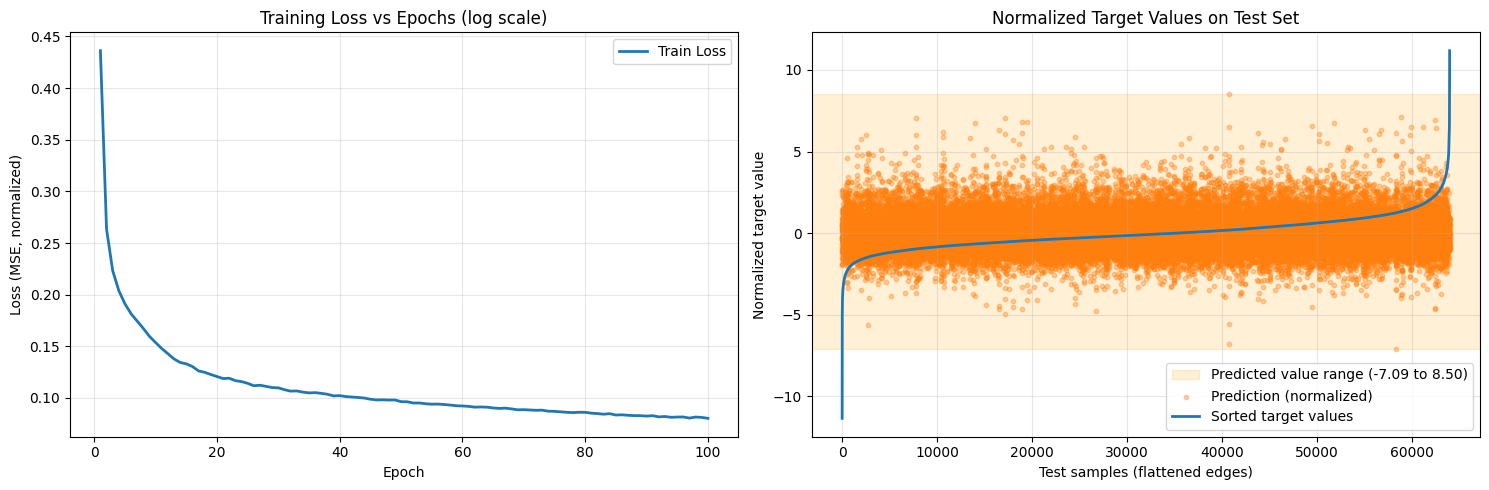

✅ Training visualizations generated.


In [ ]:
# TRAINING VISUALS: Loss curve + normalized target distribution on test set
import matplotlib.pyplot as plt
import numpy as np
import torch

# Graceful fallbacks when cell is run in a fresh kernel
epoch_history_local = globals().get("epoch_history", [])
train_loss_history_local = globals().get("train_loss_history", [])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) Loss vs Epochs (log scale for readability)
ax = axes[0]
if len(epoch_history_local) > 0 and len(train_loss_history_local) > 0:
    ax.plot(epoch_history_local, train_loss_history_local, color='tab:blue', linewidth=2, label='Train Loss')
    ax.set_yscale('linear')
    ax.set_title('Training Loss vs Epochs (log scale)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, normalized)')
    ax.grid(True, alpha=0.3)
    ax.legend()
else:
    ax.text(0.5, 0.5, 'No training history in memory\nRun training cell first', ha='center', va='center')
    ax.set_title('Training Loss vs Epochs')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE, normalized)')
    ax.grid(True, alpha=0.3)

# 2) Normalized target values vs test sample index + sorted target line
required = ['model', 'test_loader', 'device']
if all(name in globals() for name in required):
    model_is_ready = bool(USE_PRETRAINED or len(epoch_history_local) > 0)
    if not model_is_ready:
        axes[1].text(
            0.5,
            0.5,
            'Model appears untrained in this kernel\nRun Cell 11 (MODEL TRAINING) first',
            ha='center',
            va='center'
        )
        axes[1].set_title('Normalized Target Values on Test Set')
        axes[1].set_xlabel('Test samples (flattened edges)')
        axes[1].set_ylabel('Normalized target value')
        axes[1].grid(True, alpha=0.3)
    else:
        model.eval()
        all_test_targets_scaled = []
        all_test_preds_scaled = []

        with torch.no_grad():
            for batch in test_loader:
                batch = batch.to(device, non_blocking=True)
                out = model(
                    batch.x,
                    batch.edge_index,
                    edge_attr=batch.edge_attr,
                    batch=batch.batch,
                    u=batch.u,
                )
                all_test_targets_scaled.append(batch.y_edge.detach().cpu().numpy().reshape(-1))
                all_test_preds_scaled.append(out.detach().cpu().numpy().reshape(-1))

        if len(all_test_targets_scaled) > 0:
            target_values = np.concatenate(all_test_targets_scaled)
            pred_values = np.concatenate(all_test_preds_scaled)
            sample_idx = np.arange(target_values.shape[0])

            ax = axes[1]

            # Vertical value range band based on full predicted range
            band_min = float(pred_values.min())
            band_max = float(pred_values.max())
            ax.axhspan(
                band_min,
                band_max,
                color='orange',
                alpha=0.16,
                zorder=0,
                label=f'Predicted value range ({band_min:.2f} to {band_max:.2f})'
            )

            ax.scatter(sample_idx, pred_values, s=10, alpha=0.35, color='tab:orange', label='Prediction (normalized)')
            ax.plot(sample_idx, np.sort(target_values), color='tab:blue', linewidth=2, label='Sorted target values')
            ax.set_title('Normalized Target Values on Test Set')
            ax.set_xlabel('Test samples (flattened edges)')
            ax.set_ylabel('Normalized target value')
            ax.grid(True, alpha=0.3)
            ax.legend()
        else:
            axes[1].text(0.5, 0.5, 'No test batches available', ha='center', va='center')
            axes[1].set_title('Normalized Target Values on Test Set')
            axes[1].set_xlabel('Test samples (flattened edges)')
            axes[1].set_ylabel('Normalized target value')
            axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Missing model/test data in memory\nRun setup + training cells first', ha='center', va='center')
    axes[1].set_title('Normalized Target Values on Test Set')
    axes[1].set_xlabel('Test samples (flattened edges)')
    axes[1].set_ylabel('Normalized target value')
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
training_visuals_fig = fig  # Capture figure reference for evaluation export
plt.show()

print('✅ Training visualizations generated.')

# EXPORT

In [ ]:
import json
import joblib
import torch

from naming import build_model_artifact_stem

# Only export if training from scratch (not loading pre-trained)
if USE_PRETRAINED:
    print("\n⏭️  SKIPPING EXPORT (using pre-trained model)")
else:
    print("\n💾 EXPORTING MODEL AND SCALERS...\n")

    artifact_stem = build_model_artifact_stem(RUN_ID, LEARNING_RATE, EPOCHS, final_val_r2)

    # Save the active stem for downstream inference and tracing
    with open(config.SM_EXPORT_PATH / 'prefix_sm.txt', 'w', encoding='utf-8') as f:
        f.write(artifact_stem)

    run_manifest = {
        "run_id": RUN_ID,
        "artifact_stem": artifact_stem,
        "dataset_sources": {
            "node": NODE_CSV,
            "edge": EDGE_CSV,
            "global": GLOBAL_CSV,
        },
        "learning_rate": LEARNING_RATE,
        "epochs": EPOCHS,
        "final_val_r2": final_val_r2,
        "node_count": NODE_COUNT,
        "edge_count": EDGE_COUNT,
        "node_feature_dim": NODE_FEATURE_DIM,
        "edge_feature_dim": EDGE_FEATURE_DIM,
        "global_feature_dim": GLOBAL_FEATURE_DIM,
        "target_col": TARGET_COL,
    }

    # Export the scalers used by this notebook
    node_scaler_path = config.SM_EXPORT_PATH / f"{artifact_stem}_node_scaler.pkl"
    edge_feature_scaler_path = config.SM_EXPORT_PATH / f"{artifact_stem}_edge_feature_scaler.pkl"
    edge_target_scaler_path = config.SM_EXPORT_PATH / f"{artifact_stem}_edge_target_scaler.pkl"
    global_feature_scaler_path = config.SM_EXPORT_PATH / f"{artifact_stem}_global_feature_scaler.pkl"
    joblib.dump(node_continuous_scaler, node_scaler_path)
    joblib.dump(edge_feature_scaler, edge_feature_scaler_path)
    joblib.dump(edge_target_scaler, edge_target_scaler_path)
    joblib.dump(global_feature_scaler, global_feature_scaler_path)

    print(f"Scalers successfully saved:\n- {node_scaler_path}\n- {edge_feature_scaler_path}\n- {edge_target_scaler_path}\n- {global_feature_scaler_path}")

    # Export the trained GNN model as a state_dict checkpoint
    model_path = config.SM_EXPORT_PATH / f"{artifact_stem}_surrogate_model.pt"
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "node_in_dim": NODE_FEATURE_DIM,
            "edge_in_dim": EDGE_FEATURE_DIM,
            "global_in_dim": GLOBAL_FEATURE_DIM,
            "hidden_dim": 128,
            "edge_count": EDGE_COUNT,
            "checkpoint_prefix": artifact_stem,
            "run_id": RUN_ID,
            "dataset_sources": run_manifest["dataset_sources"],
            "learning_rate": LEARNING_RATE,
            "epochs": EPOCHS,
            "final_val_r2": final_val_r2,
        },
        model_path
    )

    manifest_path = config.SM_EXPORT_PATH / f"{artifact_stem}_run_manifest.json"
    with open(manifest_path, 'w', encoding='utf-8') as f:
        json.dump(run_manifest | {"model_path": model_path.name, "node_scaler_path": node_scaler_path.name, "edge_feature_scaler_path": edge_feature_scaler_path.name, "edge_target_scaler_path": edge_target_scaler_path.name, "global_feature_scaler_path": global_feature_scaler_path.name}, f, indent=2)

    print(f"\nModel checkpoint successfully saved:\n- {model_path}")
    print(f"Run manifest saved:\n- {manifest_path}")



💾 EXPORTING MODEL AND SCALERS...

Scalers succesvol opgeslagen:
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\node_scaler_data_3.1_0000.pkl
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\edge_scaler_data_3.1_0000.pkl

Model checkpoint succesvol opgeslagen:
- C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\01_surrogate_models\truss_edge_gnn_data_3.1_0000.pt


# EVALUATION & VISUALIZATION FOR OVER/UNDERFITTING

In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from model_evaluation import save_evaluation, print_evaluation_metrics

print("Collecting predictions for visualization...")

In [13]:
# Predictions vs Actual + Residual diagnostics (Train/Test)
required_objs = ["model", "device", "edge_target_scaler", "train_loader", "test_loader"]
missing_objs = [name for name in required_objs if name not in globals()]
if missing_objs:
    raise NameError(f"Missing required objects in memory: {missing_objs}. Run setup/training cells first.")

if not (USE_PRETRAINED or len(globals().get("epoch_history", [])) > 0):
    raise RuntimeError(
        "Model appears untrained in this kernel. Run Cell 11 (MODEL TRAINING) first, "
        "or set USE_PRETRAINED=True and load a checkpoint before diagnostics."
    )

def _collect_preds_trues_original(loader):
    model.eval()
    pred_batches_local = []
    true_batches_local = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device, non_blocking=True)
            out = model(
                batch.x,
                batch.edge_index,
                edge_attr=batch.edge_attr,
                batch=batch.batch,
                u=batch.u,
            )
            pred_batches_local.append(out.detach().cpu().numpy())
            true_batches_local.append(batch.y_edge.detach().cpu().numpy())

    preds_scaled_local = np.concatenate(pred_batches_local, axis=0)
    trues_scaled_local = np.concatenate(true_batches_local, axis=0)

    preds_original_local = edge_target_scaler.inverse_transform(preds_scaled_local).reshape(-1)
    trues_original_local = edge_target_scaler.inverse_transform(trues_scaled_local).reshape(-1)
    return preds_original_local, trues_original_local

# Collect predictions and targets in original kN scale
train_preds_original, train_trues_original = _collect_preds_trues_original(train_loader)
test_preds_original, test_trues_original = _collect_preds_trues_original(test_loader)

# Residuals and metrics
train_residuals = train_trues_original - train_preds_original
test_residuals = test_trues_original - test_preds_original

train_mae = float(mean_absolute_error(train_trues_original, train_preds_original))
test_mae = float(mean_absolute_error(test_trues_original, test_preds_original))
train_rmse = float(np.sqrt(mean_squared_error(train_trues_original, train_preds_original)))
test_rmse = float(np.sqrt(mean_squared_error(test_trues_original, test_preds_original)))
train_r2 = float(r2_score(train_trues_original, train_preds_original))
test_r2 = float(r2_score(test_trues_original, test_preds_original))

# Build status label for quick interpretation
r2_gap = train_r2 - test_r2
if train_r2 < 0.7 and test_r2 < 0.7:
    status = "underfitting"
elif r2_gap > 0.05:
    status = "overfitting"
else:
    status = "good_fit"

model_prefix = globals().get("prefix_sm", globals().get("PRETRAINED_MODEL_PREFIX", "unknown_model"))
metrics = {
    "train_r2": train_r2,
    "test_r2": test_r2,
    "train_mae": train_mae,
    "test_mae": test_mae,
    "train_rmse": train_rmse,
    "test_rmse": test_rmse,
    "r2_gap": float(r2_gap),
}

# Print concise metric summary
print(f"Train R2:  {train_r2:.4f}")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train MAE: {train_mae:.4f} kN")
print(f"Test MAE:  {test_mae:.4f} kN")
print(f"Status:    {status}")

# 2x2 plot: Pred vs Actual + residuals for Train/Test
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Shared limits for prediction-vs-actual plots
all_trues = np.concatenate([train_trues_original, test_trues_original])
all_preds = np.concatenate([train_preds_original, test_preds_original])
lim_low = min(all_trues.min(), all_preds.min())
lim_high = max(all_trues.max(), all_preds.max())

# Top-left: Train Pred vs Actual
ax = axes[0, 0]
ax.scatter(train_trues_original, train_preds_original, s=14, alpha=0.55, color="tab:blue", edgecolors="none", label="Train")
ax.plot([lim_low, lim_high], [lim_low, lim_high], "r--", linewidth=1.8, label="Perfect Prediction")
ax.set_title(f"Train Set: Predictions vs Actual\nR2 = {train_r2:.4f}")
ax.set_xlabel("Actual Force (kN)")
ax.set_ylabel("Predicted Force (kN)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

# Top-right: Test Pred vs Actual
ax = axes[0, 1]
ax.scatter(test_trues_original, test_preds_original, s=14, alpha=0.60, color="orange", edgecolors="none", label="Test")
ax.plot([lim_low, lim_high], [lim_low, lim_high], "r--", linewidth=1.8, label="Perfect Prediction")
ax.set_title(f"Test Set: Predictions vs Actual\nR2 = {test_r2:.4f}")
ax.set_xlabel("Actual Force (kN)")
ax.set_ylabel("Predicted Force (kN)")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

# Bottom-left: Train residuals vs predicted
ax = axes[1, 0]
ax.scatter(train_preds_original, train_residuals, s=14, alpha=0.55, color="tab:blue", edgecolors="none")
ax.axhline(0, color="red", linestyle="--", linewidth=1.8)
ax.set_title(f"Train Set: Residuals Plot\nMean Residual: {np.mean(train_residuals):.4f}")
ax.set_xlabel("Predicted Force (kN)")
ax.set_ylabel("Residuals (kN)")
ax.grid(True, alpha=0.3)

# Bottom-right: Test residuals vs predicted
ax = axes[1, 1]
ax.scatter(test_preds_original, test_residuals, s=14, alpha=0.60, color="orange", edgecolors="none")
ax.axhline(0, color="red", linestyle="--", linewidth=1.8)
ax.set_title(f"Test Set: Residuals Plot\nMean Residual: {np.mean(test_residuals):.4f}")
ax.set_xlabel("Predicted Force (kN)")
ax.set_ylabel("Residuals (kN)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
pred_residuals_fig = fig  # Used later by save_evaluation(...)
plt.show()

print("✅ Prediction/residual diagnostic plots generated.")

RuntimeError: Model appears untrained in this kernel. Run Cell 11 (MODEL TRAINING) first, or set USE_PRETRAINED=True and load a checkpoint before diagnostics.

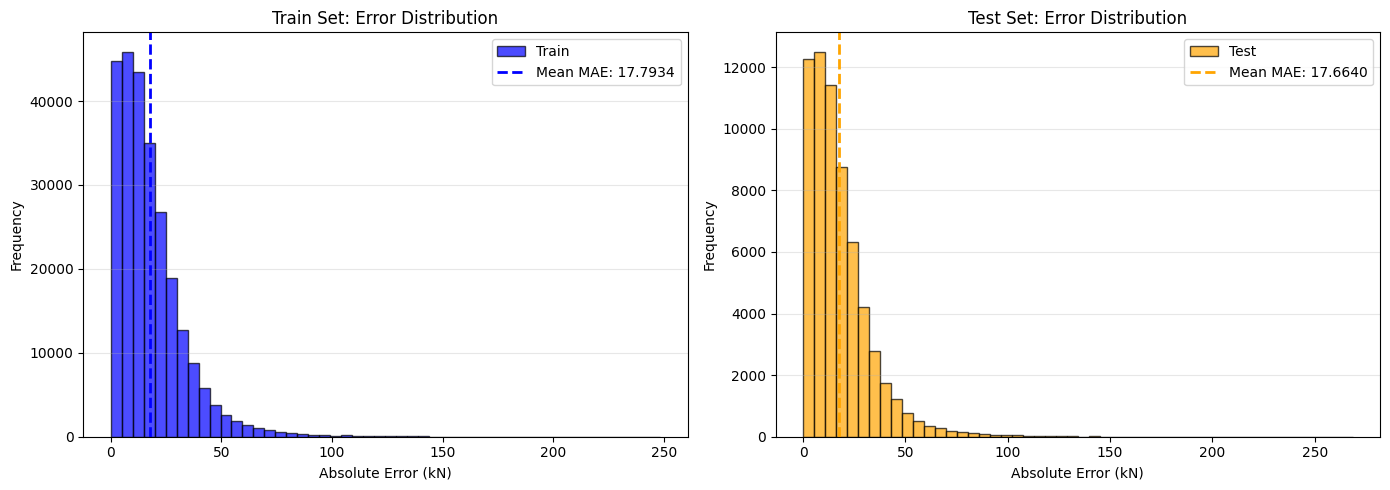

✅ Error distribution plots generated.


In [10]:
# Error distribution plots (uses residuals/MAE computed in previous diagnostics cell)
required_objs = ["train_residuals", "test_residuals", "train_mae", "test_mae"]
missing_objs = [name for name in required_objs if name not in globals()]
if missing_objs:
    raise NameError(
        f"Missing required objects in memory: {missing_objs}. Run the previous diagnostics cell first."
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Error distribution (train set)
ax = axes[0]
train_errors = np.abs(train_residuals)
ax.hist(train_errors, bins=50, alpha=0.7, edgecolor="black", color="blue", label="Train")
ax.axvline(train_mae, color="blue", linestyle="--", lw=2, label=f"Mean MAE: {train_mae:.4f}")
ax.set_xlabel("Absolute Error (kN)")
ax.set_ylabel("Frequency")
ax.set_title("Train Set: Error Distribution")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# 2. Error distribution (test set)
ax = axes[1]
test_errors = np.abs(test_residuals)
ax.hist(test_errors, bins=50, alpha=0.7, edgecolor="black", color="orange", label="Test")
ax.axvline(test_mae, color="orange", linestyle="--", lw=2, label=f"Mean MAE: {test_mae:.4f}")
ax.set_xlabel("Absolute Error (kN)")
ax.set_ylabel("Frequency")
ax.set_title("Test Set: Error Distribution")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
error_dist_fig = fig  # Used later by save_evaluation(...)
plt.show()

print("✅ Error distribution plots generated.")

In [12]:
import importlib
import config
import model_evaluation

# Ensure latest model_evaluation.py changes are loaded in notebook kernel
importlib.reload(model_evaluation)

model_artifact_stem = globals().get("artifact_stem", globals().get("PRETRAINED_MODEL_PREFIX", "unknown_model"))
export_final_val_r2 = globals().get("final_val_r2", test_r2)
architecture_summary = {
    "model_class": "TrussEdgeNNConv",
    "node_in_dim": NODE_FEATURE_DIM,
    "edge_in_dim": EDGE_FEATURE_DIM,
    "global_in_dim": GLOBAL_FEATURE_DIM,
    "hidden_dim": 128,
    "edge_count": EDGE_COUNT,
    "device": str(device),
    "node_feature_dim": NODE_FEATURE_DIM,
    "dataset_sources": {
        "node": NODE_CSV,
        "edge": EDGE_CSV,
        "global": GLOBAL_CSV,
    },
}
experiment_notes = (
    f"USE_PRETRAINED={USE_PRETRAINED}; "
    f"USE_TRAINING_TIME_LIMIT={USE_TRAINING_TIME_LIMIT}; "
    f"source_node_csv={NODE_CSV}; "
    f"source_edge_csv={EDGE_CSV}; "
    f"source_global_csv={GLOBAL_CSV}"
)

# SAVE ALL EVALUATION RESULTS TO FILE
saved_files = model_evaluation.save_evaluation(
    model_prefix=model_artifact_stem,
    dataset_name=f"{NODE_CSV} | {EDGE_CSV} | {GLOBAL_CSV}",
    metrics=metrics,
    pred_residuals_fig=pred_residuals_fig,
    error_dist_fig=error_dist_fig,
    training_visuals_fig=globals().get("training_visuals_fig"),
    node_count=NODE_COUNT,
    edge_count=EDGE_COUNT,
    export_path=config.SM_DATA_PATH,
    status=status,
    run_id=RUN_ID,
    artifact_stem=model_artifact_stem,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,
    final_val_r2=export_final_val_r2,
    strict_dataset_label=f"{NODE_CSV} | {EDGE_CSV} | {GLOBAL_CSV}",
    source_dataset_path=str(config.GH_DATA_PATH / EDGE_CSV),
    architecture_summary=architecture_summary,
    experiment_notes=experiment_notes,
    train_split_ratio=TRAIN_SPLIT_RATIO,
    random_seed=RANDOM_SEED,
    source_notebook="c21_surrogate_model_training.ipynb",
)



Saving evaluation results for: data_4_0000

Metrics saved: metrics_20260414_102946.json
Predictions plot saved: 01_predictions_residuals_20260414_102946.png
Error distribution saved: 02_error_distribution_20260414_102946.png
Architecture summary saved: model_architecture_20260414_102946.txt
Manifest saved: run_manifest_20260414_102946.json
Experiment card saved: experiment_card_20260414_102946.md
README saved: README.md

All evaluation files saved to:
   C:\Users\jaspe\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\02_surrogate_model_data\ID20260414_101850_2026-04-14_102946



## Interpretation Guide

### What to look for:

**OVERFITTING** 🔴 (Train performs much better than Test):
- Train R² >> Test R² (gap > 0.05)
- Train residuals are much smaller than test residuals
- Test error histogram has a heavier right tail
- Predictions vs Actual scatter: train points closer to red line than test points

**UNDERFITTING** 🔴 (Both train and test perform poorly):
- Both R² scores are low (< 0.7)
- Both residuals show large systematic patterns
- Both predictions scatter far from the red diagonal line
- High MAE/RMSE on both train and test

**GOOD FIT** ✅ (Train and Test perform similarly):
- Train and Test R² are close (gap < 0.05)
- Both residuals are centered around 0 with similar spread
- Both scatter plots show points close to diagonal line
- Error distributions are similar and centered

### Remedies:

If **Overfitting**:
- **Gather more training data** (most effective long-term solution—model memorizes less with more diverse samples)
- Add dropout layers to the model
- Increase weight decay (L2 regularization)
- Use early stopping on validation loss
- Try reducing model hidden_dim (e.g., 128 → 64)

If **Underfitting**:
- Increase hidden_dim (e.g., 128 → 256)
- Add more GNN layers
- Train for more epochs
- Check if the model has enough capacity for the problem

If **Good Fit**: ✅ Deploy and use in downstream tasks!